**Prediksi Pemilihan Gaya Belajar Menggunakan Algoritma Random Forest Klasifikasi**

Dataset yang digunakan memiliki 1.210 entri dengan 17 atribut, yang terdiri dari data numerik skala 1-5 dan 2 data kategorikal. hasil identifikasi berupa Visual, Auditori, atau Kinestetik.


**1. Import library & dataset**

In [ ]:
#import library
import numpy as np
import pandas as pd
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from collections import Counter
import shap

In [ ]:
#Import Dataset
learn_style = pd.read_csv("/content/sample_data/Learning_Style.csv")
learn_style

,Gender,Age,I learn better by reading what the teacher writes on the chalkboard.,"When I read instructions, I remember them better.",I understand better when I read instructions.,I learn better by reading than by listening to someone.,I learn more by reading textbooks than by listening to lectures.,When the teacher tells me the instructions I understand better,"When someone tells me how to do something in class, I learn it better.",I remember things I have heard in class better than things I have read.,I learn better in class when the teacher gives a lecture.,I learn better in class when I listen to someone.,I prefer to learn by doing something in class.,"When I do things in class, I learn better.",I enjoy learning in class by doing experiments.,I understand things better in class when I participate in role-playing.,Learner
0,Male,16,5,4,4,4,3,3,2,4,3,4,3,4,3,4,A
1,Male,18,3,4,3,3,4,2,4,3,2,2,3,2,3,3,A
2,Female,21,4,4,4,5,5,4,4,3,4,4,5,5,5,3,A
3,Female,21,5,5,5,5,4,4,4,4,4,4,3,4,5,5,A
4,Female,19,3,5,4,4,4,3,3,3,3,3,3,3,4,4,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1205,Male,21,4,4,4,2,2,4,4,4,4,1,3,2,3,2,V
1206,Female,20,2,2,4,4,2,1,2,5,3,4,1,4,2,3,V
1207,Male,21,4,4,4,2,2,4,4,4,4,1,3,2,3,2,V
1208,Female,20,2,2,4,4,2,1,2,5,3,4,1,4,2,3,V


**2. Processing dan Cleaning Data**

In [ ]:
learn_style.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1210 entries, 0 to 1209
Data columns (total 17 columns):
 #   Column                                                                   Non-Null Count  Dtype 
---  ------                                                                   --------------  ----- 
 0   Gender                                                                   1210 non-null   object
 1   Age                                                                      1210 non-null   int64 
 2   I learn better by reading what the teacher writes on the chalkboard.     1210 non-null   int64 
 3   When I read instructions, I remember them better.                        1210 non-null   int64 
 4   I understand better when I read instructions.                            1210 non-null   int64 
 5   I learn better by reading than by listening to someone.                  1210 non-null   int64 
 6   I learn more by reading textbooks than by listening to lectures.         1210 no

In [ ]:
learn_style.shape

(1210, 17)

In [ ]:
# Cek data nilai kosong
learn_style.isnull().sum()

,0
Gender,0
Age,0
I learn better by reading what the teacher writes on the chalkboard.,0
"When I read instructions, I remember them better.",0
I understand better when I read instructions.,0
I learn better by reading than by listening to someone.,0
I learn more by reading textbooks than by listening to lectures.,0
When the teacher tells me the instructions I understand better,0
"When someone tells me how to do something in class, I learn it better.",0
I remember things I have heard in class better than things I have read.,0


In [ ]:
# 1. One-Hot Encoding untuk fitur 'Gender'
learn_style = pd.get_dummies(learn_style, columns=['Gender'], prefix='Gender', dtype=int)

# 2. Ordinal Encoding untuk fitur 'Learner'
# Mapping
learner_order = [['V', 'A', 'K']]

# Inisialisasi encoder dengan urutan kategori custom
enc = OrdinalEncoder(categories=learner_order)

# Transform kolom 'Learner' menjadi bentuk numerik
learn_style[['Learner']] = enc.fit_transform(learn_style[['Learner']])

In [ ]:
# Menampilkan hasil
print("Hasil dataset setelah encoding:")
print(learn_style)

Hasil dataset setelah encoding:
      Age  \
0      16   
1      18   
2      21   
3      21   
4      19   
...   ...   
1205   21   
1206   20   
1207   21   
1208   20   
1209   17   

      I learn better by reading what the teacher writes on the chalkboard.  \
0                                                     5                      
1                                                     3                      
2                                                     4                      
3                                                     5                      
4                                                     3                      
...                                                 ...                      
1205                                                  4                      
1206                                                  2                      
1207                                                  4                      
1208                           

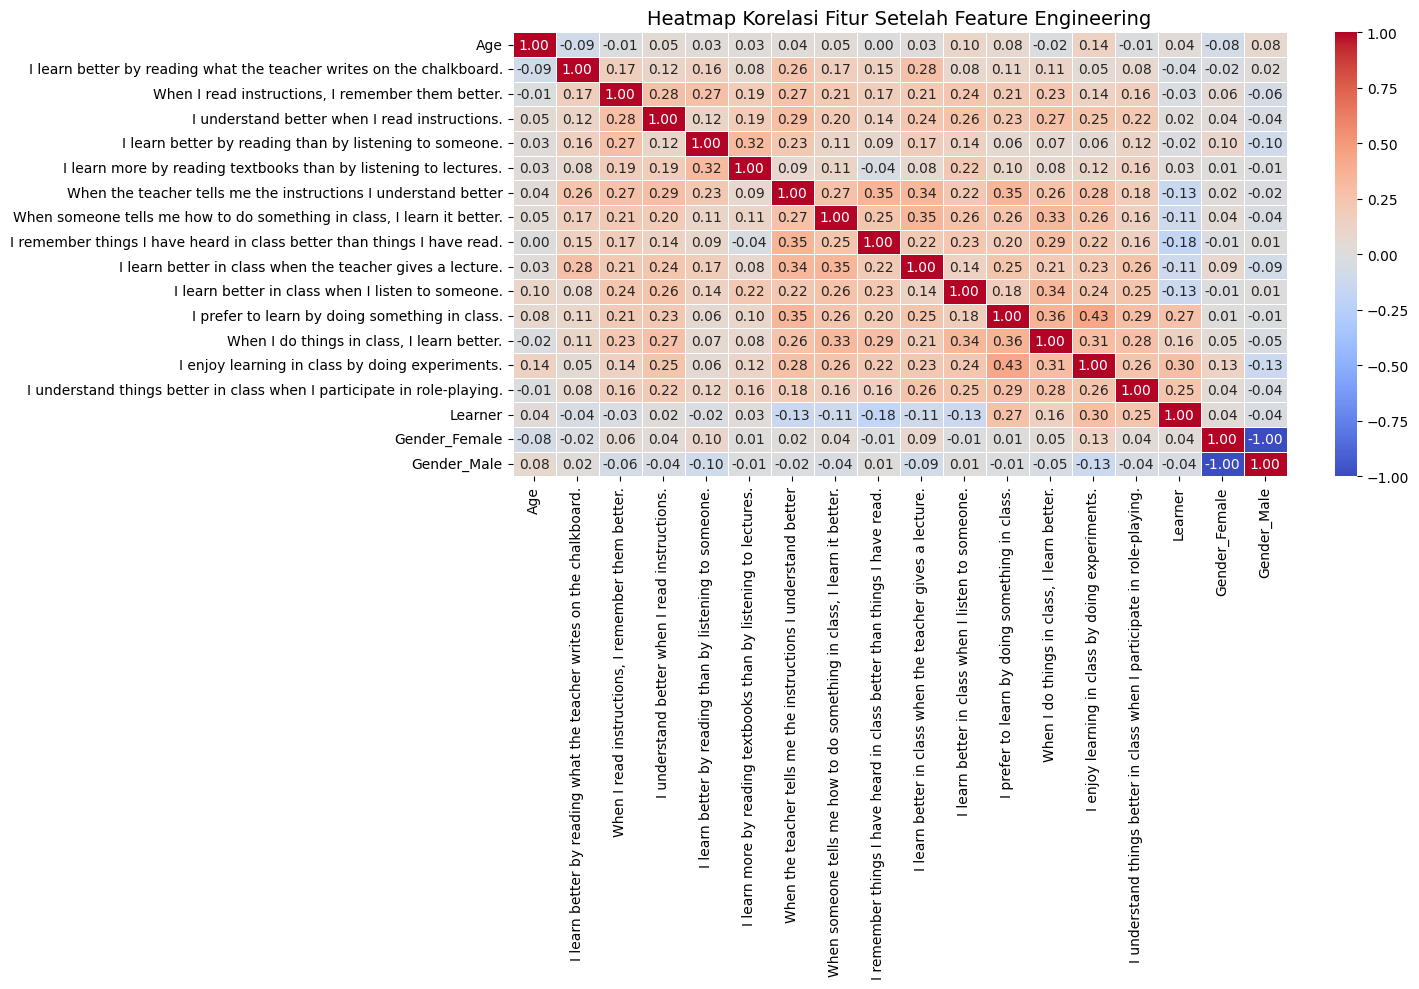

In [ ]:
# 1. Hitung korelasi antar fitur numerik (korelasi untuk mengukur hubungan antar dua variabel)
correlation_matrix = learn_style.corr()

# 2. Buat ukuran dan tampilan heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 3. Tambahkan judul
plt.title('Heatmap Korelasi Fitur Setelah Feature Engineering', fontsize=14)

# 4. Tampilkan plot
plt.tight_layout()
plt.show()

In [ ]:
# Pisahkan fitur (X) dan target (y)
X = learn_style.drop('Learner', axis=1)  # Semua kolom kecuali target
y = learn_style['Learner']  # Target

In [ ]:
# Split data menjadi training dan testing (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )
X

,Age,I learn better by reading what the teacher writes on the chalkboard.,"When I read instructions, I remember them better.",I understand better when I read instructions.,I learn better by reading than by listening to someone.,I learn more by reading textbooks than by listening to lectures.,When the teacher tells me the instructions I understand better,"When someone tells me how to do something in class, I learn it better.",I remember things I have heard in class better than things I have read.,I learn better in class when the teacher gives a lecture.,I learn better in class when I listen to someone.,I prefer to learn by doing something in class.,"When I do things in class, I learn better.",I enjoy learning in class by doing experiments.,I understand things better in class when I participate in role-playing.,Gender_Female,Gender_Male
0,16,5,4,4,4,3,3,2,4,3,4,3,4,3,4,0,1
1,18,3,4,3,3,4,2,4,3,2,2,3,2,3,3,0,1
2,21,4,4,4,5,5,4,4,3,4,4,5,5,5,3,1,0
3,21,5,5,5,5,4,4,4,4,4,4,3,4,5,5,1,0
4,19,3,5,4,4,4,3,3,3,3,3,3,3,4,4,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1205,21,4,4,4,2,2,4,4,4,4,1,3,2,3,2,0,1
1206,20,2,2,4,4,2,1,2,5,3,4,1,4,2,3,1,0
1207,21,4,4,4,2,2,4,4,4,4,1,3,2,3,2,0,1
1208,20,2,2,4,4,2,1,2,5,3,4,1,4,2,3,1,0


In [ ]:
# Tampilkan jumlah data
print(f"Jumlah total data     : {len(X)}")
print(f"Jumlah data training  : {len(X_train)}")
print(f"Jumlah data testing   : {len(X_test)}")

# Jika ingin lihat distribusi kelas di masing-masing bagian
print("\nDistribusi kelas di data training:")
print(y_train.value_counts())

print("\nDistribusi kelas di data testing:")
print(y_test.value_counts())

Jumlah total data     : 1210
Jumlah data training  : 968
Jumlah data testing   : 242

Distribusi kelas di data training:
Learner
2.0    540
1.0    228
0.0    200
Name: count, dtype: int64

Distribusi kelas di data testing:
Learner
2.0    139
1.0     58
0.0     45
Name: count, dtype: int64


In [ ]:
print(X.shape)  # pastikan X adalah data sebelum PCA

(1210, 17)


**3. Pemodelan menggunakan Algoritma Random Forest**

In [ ]:
# Model RF default
model_default = RandomForestClassifier(random_state=42)
model_default.fit(X_train, y_train)

# Prediksi di data uji
y_pred_default = model_default.predict(X_test)

# Evaluasi performa
print("📊 Classification Report:")
print(classification_report(y_test, y_pred_default))

print("📉 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_default))

📊 Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.69      0.81        45
         1.0       0.90      0.76      0.82        58
         2.0       0.83      0.96      0.89       139

    accuracy                           0.86       242
   macro avg       0.90      0.80      0.84       242
weighted avg       0.87      0.86      0.86       242

📉 Confusion Matrix:
[[ 31   1  13]
 [  0  44  14]
 [  1   4 134]]


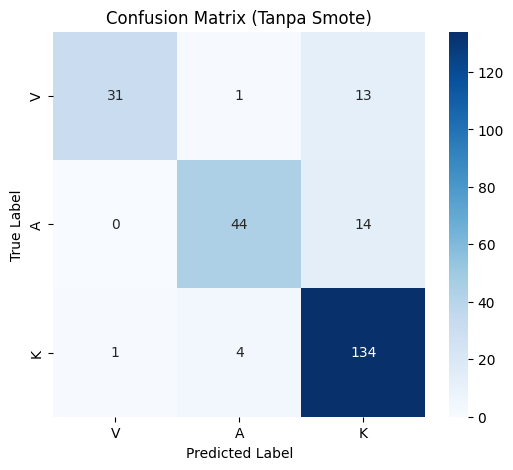

In [ ]:
# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred_default)

labels = ['V', 'A', 'K']

# Visualisasi heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Tanpa Smote)')
plt.show()

In [ ]:
# Gunakan Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Hitung cross-validation scores
cv_scores = cross_val_score(model_default, X_train, y_train, cv=cv, scoring='accuracy')

# Output hasil
print("✅ Akurasi per fold:", np.round(cv_scores, 4))
print("📊 Rata-rata Akurasi:", np.round(cv_scores.mean(), 4))
print("📉 Standar Deviasi:", np.round(cv_scores.std(), 4))

✅ Akurasi per fold: [0.8264 0.8347 0.8017 0.8512 0.8223]
📊 Rata-rata Akurasi: 0.8273
📉 Standar Deviasi: 0.0162


2. Pemodelan dengan Pipeline

In [ ]:
# Pipeline dengan preprocessing + model
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))/
])


In [ ]:
#latih model dengan data latih
pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=0.95)),
                ('smote', SMOTE(random_state=42)),
                ('rf', RandomForestClassifier(random_state=42))])

In [ ]:
#prediksi di data uji
y_pred = pipeline.predict(X_test)


In [ ]:
#evaluasi model
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("📉 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

📊 Classification Report:
              precision    recall  f1-score   support

         0.0       0.80      0.78      0.79        45
         1.0       0.85      0.81      0.83        58
         2.0       0.88      0.91      0.89       139

    accuracy                           0.86       242
   macro avg       0.84      0.83      0.84       242
weighted avg       0.86      0.86      0.86       242

📉 Confusion Matrix:
[[ 35   2   8]
 [  2  47   9]
 [  7   6 126]]


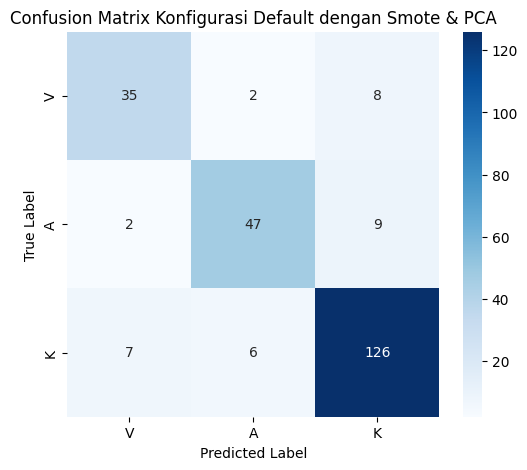

In [ ]:
# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred)


labels = ['V', 'A', 'K']

# Visualisasi heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Konfigurasi Default dengan Smote & PCA')
plt.show()

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')

print("✅ Accuracy per fold:", scores)
print("📊 Mean Accuracy:", scores.mean())
print("📉 Std Dev:", scores.std())

✅ Accuracy per fold: [0.82644628 0.82231405 0.86363636 0.87603306 0.85950413]
📊 Mean Accuracy: 0.849586776859504
📉 Std Dev: 0.021328079174485832


**Visualisasi PCA 2 Dimensi**

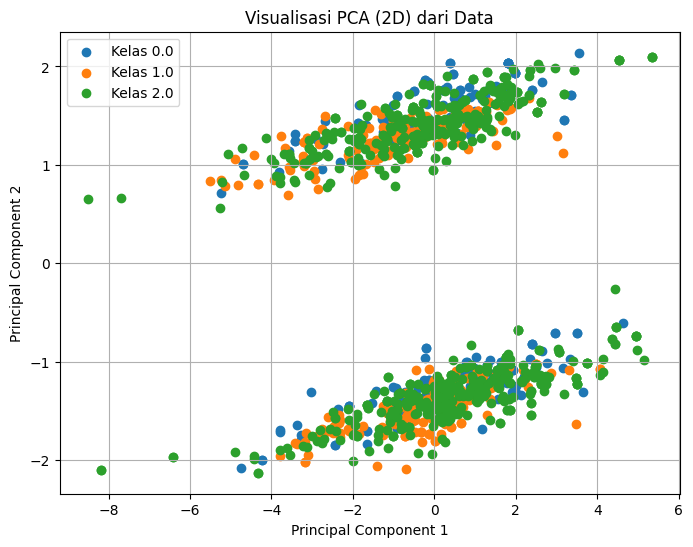

In [ ]:
# Scaling data terlebih dahulu
X_scaled = scaler.fit_transform(X)

# Hanya mengambil dua komponen utama (PC1 dan PC2)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualisasi hasil PCA
plt.figure(figsize=(8,6))

# Plot data
for i, label in enumerate(set(y)):
    plt.scatter(X_pca[y == label, 0], X_pca[y == label, 1], label=f'Kelas {label}')

plt.title('Visualisasi PCA (2D) dari Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

Semakin jauh titik ke arah kanan/kiri pada sumbu X/PC1, maka menunjukkan perbedaan ciri antar data positive dan negatif.

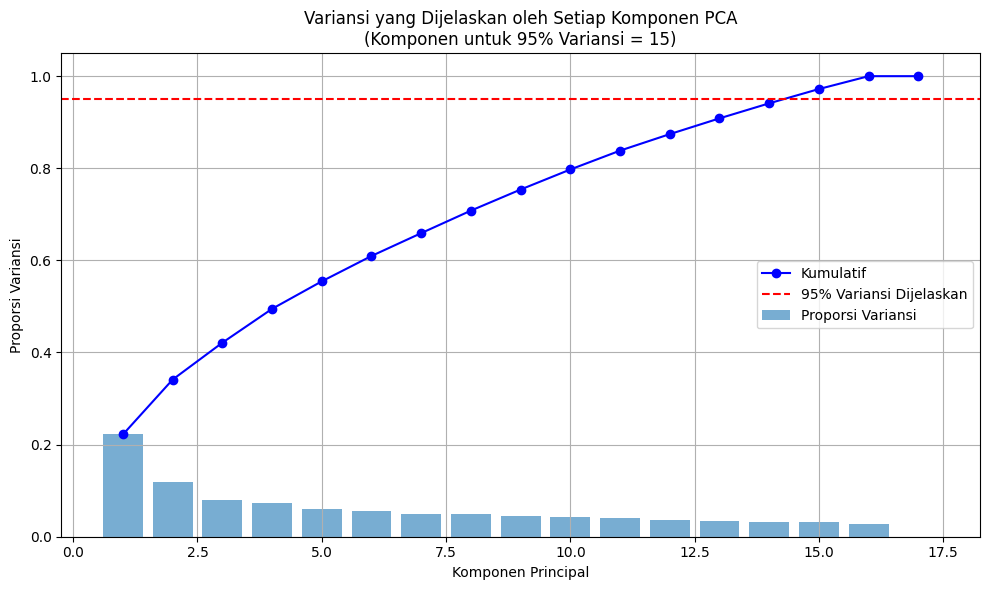

In [ ]:
# PCA tanpa batasan n_components untuk melihat semua komponen
pca_full = PCA()
pca_full.fit(X_scaled)

# Variansi masing-masing komponen
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Menetukan komponen yang diperlukan untuk mencapai 95%
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

# Visualisasi
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.6, label='Proporsi Variansi')
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='blue', label='Kumulatif')

# Garis horizontal di 95%
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Variansi Dijelaskan')
plt.title(f'Variansi yang Dijelaskan oleh Setiap Komponen PCA\n(Komponen untuk 95% Variansi = {n_components_95})')
plt.xlabel('Komponen Principal')
plt.ylabel('Proporsi Variansi')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Pemodelan RF menggunakan Grid Search dengan parameter grid

In [ ]:
param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 10, 20, 30], #batas kedalaman pohon
    'rf__min_samples_split': [2, 5, 10], #jlh minumum pembagian node
    'rf__min_samples_leaf': [1, 2, 4], #jlh minimum setiap daun
    'rf__max_features': ['sqrt', 'log2'] #jlh maks fitur pada tiap split
}

**Grid Search**

In [ ]:
grid_search = GridSearchCV(
    pipeline, param_grid, cv=5, n_jobs=-1, verbose=1
    )

In [ ]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=0.95)),
                                       ('smote', SMOTE(random_state=42)),
                                       ('rf',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'rf__max_depth': [None, 10, 20, 30],
                         'rf__max_features': ['sqrt', 'log2'],
                         'rf__min_samples_leaf': [1, 2, 4],
                         'rf__min_samples_split': [2, 5, 10],
                         'rf__n_estimators': [100, 200, 300]},
             verbose=1)

In [ ]:
# 2. Ambil model terbaik dari grid search
best_model = grid_search.best_estimator_

In [ ]:
# evaluasi cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(best_model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

# 5. Tampilkan hasil
print("✅ Accuracy per fold:", scores)
print("📊 Mean Accuracy:", scores.mean())
print("📉 Std Dev:", scores.std())

✅ Accuracy per fold: [0.83471074 0.79752066 0.88429752 0.88429752 0.87603306]
📊 Mean Accuracy: 0.8553719008264462
📉 Std Dev: 0.034275109674921866



✅ Best Parameters:
{'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 300}
📊 Classification Report:
              precision    recall  f1-score   support

         0.0       0.80      0.78      0.79        45
         1.0       0.88      0.79      0.84        58
         2.0       0.88      0.92      0.90       139

    accuracy                           0.86       242
   macro avg       0.85      0.83      0.84       242
weighted avg       0.86      0.86      0.86       242


📉 Confusion Matrix:


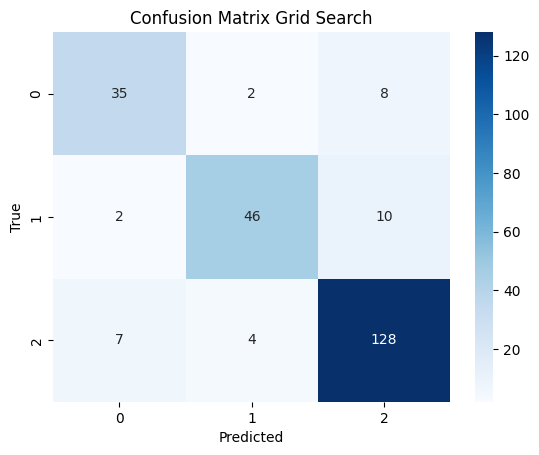

In [ ]:
# Prediksi
y_pred_grid = grid_search.predict(X_test)

print("\n✅ Best Parameters:")
print(grid_search.best_params_)

# Evaluasi
print("📊 Classification Report:")
print(classification_report(y_test, y_pred_grid))

print("\n📉 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_grid)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Grid Search')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

**Random Search**

In [ ]:
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=30,  # jumlah kombinasi acak yang ingin diuji
    cv=5,
    n_jobs=-1, #batas core yang digunakan
    verbose=1, #mengatur seberapa banyak informasi yang ditampilkan
    random_state=42
)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('pca', PCA(n_components=0.95)),
                                             ('smote', SMOTE(random_state=42)),
                                             ('rf',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'rf__max_depth': [None, 10, 20, 30],
                                        'rf__max_features': ['sqrt', 'log2'],
                                        'rf__min_samples_leaf': [1, 2, 4],
                                        'rf__min_samples_split': [2, 5, 10],
                                        'rf__n_estimators': [100, 200, 300]},
                   random_state=42, verbose=1)


✅ Best Parameters:
{'rf__n_estimators': 100, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 1, 'rf__max_features': 'log2', 'rf__max_depth': 20}
📊 Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.78      0.80        45
         1.0       0.89      0.83      0.86        58
         2.0       0.88      0.93      0.91       139

    accuracy                           0.88       242
   macro avg       0.87      0.84      0.86       242
weighted avg       0.88      0.88      0.88       242


📉 Confusion Matrix:


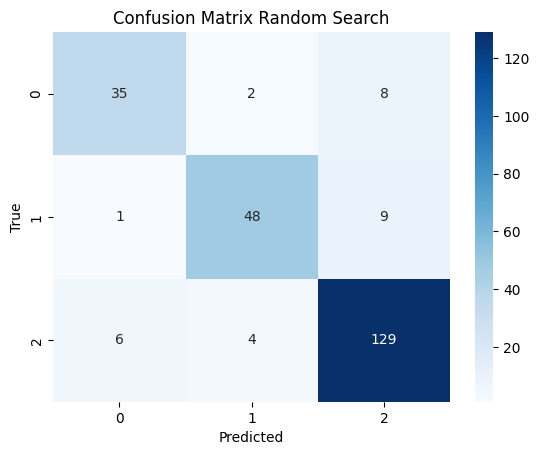

In [ ]:
# Prediksi
y_pred_random = random_search.predict(X_test)

print("\n✅ Best Parameters:")
print(random_search.best_params_)

# Evaluasi
print("📊 Classification Report:")
print(classification_report(y_test, y_pred_random))

# Confusion Matrix
print("\n📉 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_random)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Random Search')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [ ]:
# evaluasi cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(random_search, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

# 5. Tampilkan hasil
print("✅ Accuracy per fold:", scores)
print("📊 Mean Accuracy:", scores.mean())
print("📉 Std Dev:", scores.std())

✅ Accuracy per fold: [0.82231405 0.81404959 0.88429752 0.90082645 0.87190083]
📊 Mean Accuracy: 0.8586776859504133
📉 Std Dev: 0.03441431870025954


**4. Evaluation Model** <br>

In [ ]:
# Inisialisasi SHAP
explainer = shap.TreeExplainer(model_default)
shap_values = explainer.shap_values(X_test)

In [ ]:
print("SHAP Values (Array):")
print(np.array(shap_values).shape)

SHAP Values (Array):
(242, 17, 3)


**SHAP summary plot** <br>
menjelaskan fitur-fitur apa saja yang paling berpengaruh terhadap prediksi model <br>
🔴 Merah = Nilai fitur tinggi (misal jawaban siswa “setuju banget”)

🔵 Biru = Nilai fitur rendah (misal jawaban siswa “tidak setuju”)



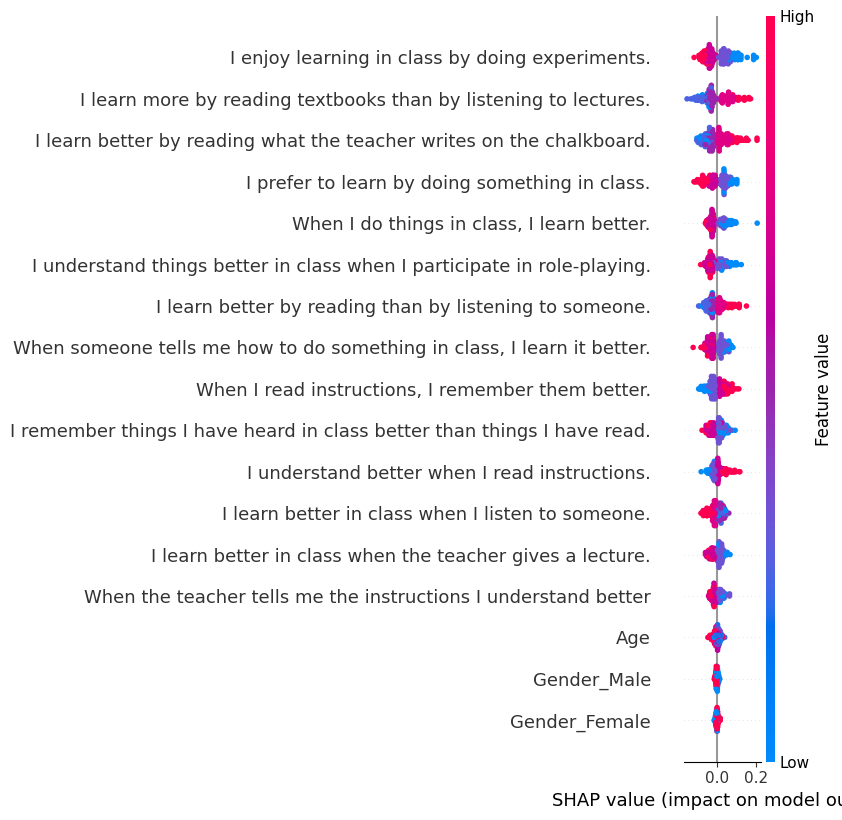

In [ ]:
# Transpose dari (242, 17, 3) --> (3, 242, 17)
shap_values_transposed = np.transpose(shap_values, (2, 0, 1))

# visualisasi:
shap.summary_plot(shap_values_transposed[1], X_test, feature_names=X_test.columns)

**Penjelesan dalam penelitian** <br>
Visualisasi SHAP (SHapley Additive exPlanations) digunakan untuk menganalisis kontribusi masing-masing fitur terhadap hasil prediksi model. Berdasarkan summary plot yang dihasilkan, terlihat bahwa fitur-fitur yang berasal dari pernyataan kuisioner memiliki kontribusi yang paling dominan terhadap prediksi model dibandingkan dengan fitur demografis seperti usia dan jenis kelamin. Beberapa fitur dengan pengaruh paling signifikan antara lain pernyataan "I enjoy learning in class by doing experiments", "I learn more by reading textbooks than by listening to lectures", dan "I learn better by reading what the teacher writes on the chalkboard". Titik-titik berwarna merah yang muncul di sisi kanan pada fitur-fitur tersebut menunjukkan bahwa nilai yang tinggi (misalnya siswa yang sangat setuju terhadap pernyataan tersebut) berkontribusi positif dalam mendorong model memprediksi kelas tertentu (misalnya gaya belajar kinestetik atau visual), sedangkan titik-titik biru di sisi kiri menandakan bahwa nilai rendah pada fitur tersebut justru menurunkan kemungkinan prediksi terhadap kelas tersebut. Hal ini menunjukkan bahwa respons siswa terhadap pernyataan-pernyataan tertentu memiliki peran besar dalam membentuk hasil prediksi gaya belajar. Sementara itu, variabel demografis seperti Age, Gender_Male, dan Gender_Female memiliki dampak yang relatif kecil, terlihat dari posisinya yang berada di bagian bawah dan nilai SHAP yang mendekati nol. Hasil ini mengindikasikan bahwa pendekatan berbasis fitur perilaku (kuisioner) lebih informatif dalam memprediksi gaya belajar dibandingkan dengan informasi demografis.

**5. Uji Hasil Model Prediksi**

In [ ]:
# Data input uji (harus sesuai urutan fitur yang digunakan dalam X)
test_data = pd.DataFrame({
    'Age': [17],
    'I learn better by reading what the teacher writes on the chalkboard.': [3],
    'When I read instructions, I remember them better.': [4],
    'I understand better when I read instructions.': [3],
    'I learn better by reading than by listening to someone.': [4],
    'I learn more by reading textbooks than by listening to lectures.': [4],
    'When the teacher tells me the instructions I understand better': [3],
    'When someone tells me how to do something in class, I learn it better.': [4],
    'I remember things I have heard in class better than things I have read.': [4],
    'I learn better in class when the teacher gives a lecture.': [5],
    'I learn better in class when I listen to someone.': [4],
    'I prefer to learn by doing something in class.': [3],
    'When I do things in class, I learn better.': [4],
    'I enjoy learning in class by doing experiments.': [3],
    'I understand things better in class when I participate in role-playing.': [3],
    'Gender_Female': [0],
    'Gender_Male': [1]
})

# Pastikan kolom sama urutannya dengan X
test_data = test_data[X.columns]  # X adalah data training fitur (tanpa target)

# Tangani missing value jika ada (agar aman saat masuk ke pipeline)
test_data.fillna(test_data.median(numeric_only=True), inplace=True)

# Prediksi menggunakan pipeline hasil RandomizedSearchCV
prediction = random_search.predict(test_data)

# Mapping label hasil prediksi
label_map = {0: 'Visual', 1: 'Auditori', 2: 'Kinestetik'}
predicted_label = label_map.get(prediction[0], 'Unknown')

# Output hasil
print("📊 Hasil Prediksi:", prediction[0])
print("🎯 Gaya Belajar Anda:", predicted_label)


📊 Hasil Prediksi: 0.0
🎯 Gaya Belajar Anda: Visual


In [ ]:
# Data input uji (harus sesuai urutan fitur yang digunakan dalam X)
test_data = pd.DataFrame({
    'Age': [18],
    'I learn better by reading what the teacher writes on the chalkboard.': [3],
    'When I read instructions, I remember them better.': [4],
    'I understand better when I read instructions.': [3],
    'I learn better by reading than by listening to someone.': [3],
    'I learn more by reading textbooks than by listening to lectures.': [4],
    'When the teacher tells me the instructions I understand better': [2],
    'When someone tells me how to do something in class, I learn it better.': [4],
    'I remember things I have heard in class better than things I have read.': [3],
    'I learn better in class when the teacher gives a lecture.': [2],
    'I learn better in class when I listen to someone.': [2],
    'I prefer to learn by doing something in class.': [3],
    'When I do things in class, I learn better.': [2],
    'I enjoy learning in class by doing experiments.': [3],
    'I understand things better in class when I participate in role-playing.': [3],
    'Gender_Female': [0],
    'Gender_Male': [1]
})

# Pastikan kolom sama urutannya dengan X
test_data = test_data[X.columns]  # X adalah data training fitur (tanpa target)

# Tangani missing value jika ada (agar aman saat masuk ke pipeline)
test_data.fillna(test_data.median(numeric_only=True), inplace=True)

# Prediksi menggunakan pipeline hasil RandomizedSearchCV
prediction = random_search.predict(test_data)

# Mapping label hasil prediksi
label_map = {0: 'Visual', 1: 'Auditori', 2: 'Kinestetik'}
predicted_label = label_map.get(prediction[0], 'Unknown')

# Output hasil
print("📊 Hasil Prediksi:", prediction[0])
print("🎯 Gaya Belajar Anda:", predicted_label)


📊 Hasil Prediksi: 1.0
🎯 Gaya Belajar Anda: Auditori


In [ ]:
# Data input uji (harus sesuai urutan fitur yang digunakan dalam X)
test_data = pd.DataFrame({
    'Age': [19],
    'I learn better by reading what the teacher writes on the chalkboard.': [3],
    'When I read instructions, I remember them better.': [4],
    'I understand better when I read instructions.': [3],
    'I learn better by reading than by listening to someone.': [2],
    'I learn more by reading textbooks than by listening to lectures.': [1],
    'When the teacher tells me the instructions I understand better': [3],
    'When someone tells me how to do something in class, I learn it better.': [2],
    'I remember things I have heard in class better than things I have read.': [2],
    'I learn better in class when the teacher gives a lecture.': [3],
    'I learn better in class when I listen to someone.': [4],
    'I prefer to learn by doing something in class.': [5],
    'When I do things in class, I learn better.': [4],
    'I enjoy learning in class by doing experiments.': [4],
    'I understand things better in class when I participate in role-playing.': [3],
    'Gender_Female': [1],
    'Gender_Male': [0]
})

# Pastikan kolom sama urutannya dengan X
test_data = test_data[X.columns]  # X adalah data training fitur (tanpa target)

# Tangani missing value jika ada (agar aman saat masuk ke pipeline)
test_data.fillna(test_data.median(numeric_only=True), inplace=True)

# Prediksi menggunakan pipeline hasil RandomizedSearchCV
prediction = random_search.predict(test_data)

# Mapping label hasil prediksi
label_map = {0: 'Visual', 1: 'Auditori', 2: 'Kinestetik'}
predicted_label = label_map.get(prediction[0], 'Unknown')

# Output hasil
print("📊 Hasil Prediksi:", prediction[0])
print("🎯 Gaya Belajar Anda:", predicted_label)


📊 Hasil Prediksi: 2.0
🎯 Gaya Belajar Anda: Kinestetik


**6. Simpan file model**

In [ ]:
filename = 'learnstylemodel.sav'
pickle.dump(random_search, open(filename, 'wb'))